In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
data = pd.read_csv("all-data.csv", encoding='latin1', header=None)

In [ ]:
data.columns = ["sentiment", "text"]

In [ ]:
stop_words = set(stopwords.words("english"))

In [ ]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [ ]:
data["clean_text"] = data["text"].apply(clean_text)

In [ ]:
data

,sentiment,text,clean_text
0,neutral,"According to Gran , the company has no plans t...",according gran company plans move production r...
1,neutral,Technopolis plans to develop in stages an area...,technopolis plans develop stages area less squ...
2,negative,The international electronic industry company ...,international electronic industry company elco...
3,positive,With the new production plant the company woul...,new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,according company updated strategy years baswa...
...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,london marketwatch share prices ended lower lo...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,rinkuskiai beer sales fell per cent million li...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,operating profit fell eur mn eur mn including ...
4844,negative,Net sales of the Paper segment decreased to EU...,net sales paper segment decreased eur mn secon...


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["clean_text"])
y = data["sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7381443298969073

Classification Report:

              precision    recall  f1-score   support

    negative       0.81      0.44      0.57       110
     neutral       0.72      0.96      0.82       571
    positive       0.78      0.42      0.55       289

    accuracy                           0.74       970
   macro avg       0.77      0.60      0.65       970
weighted avg       0.75      0.74      0.71       970



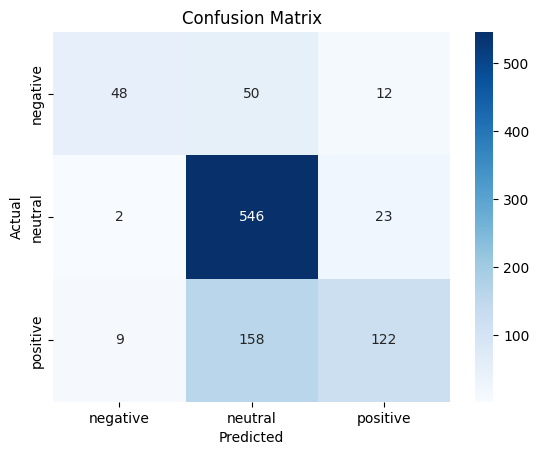

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_sentiment(text):

    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)

    return prediction[0]

In [ ]:
print("\nExample Predictions")

print("1:", predict_sentiment("Tesla stock expected to grow after strong earnings"))
print("2:", predict_sentiment("Company suffers major financial losses"))
print("3:", predict_sentiment("The company announced a new investment plan"))
print("3:", predict_sentiment("clothing retail chain sepp l sales increased eur mn operating profit rose eur mn eur mn"))


Example Predictions
1: positive
2: neutral
3: neutral
3: positive


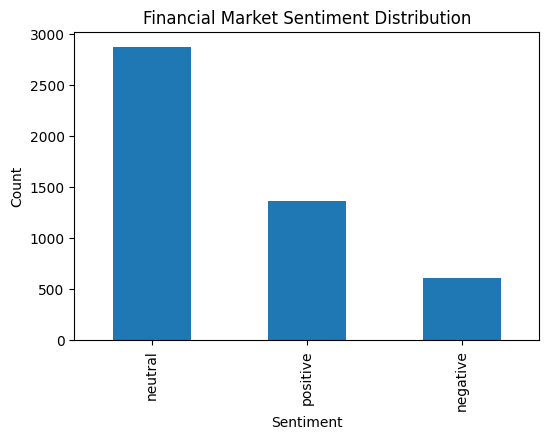

In [ ]:
sentiment_counts = data['sentiment'].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')

plt.title("Financial Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()